# (노트) 경사하강법, 텐서플로우

- toc:true
- branch: master
- badges: true
- comments: true
- author: 신록예찬
- categories: [데이터과학]

### About this doc 

`-` 2021년 데이터과학 강의노트 $\to$ 2022년 데이터과학 강의노트로 개선 

### imports 

In [78]:
import tensorflow as tf
import numpy as np 
import tensorflow.experimental.numpy as tnp 

In [79]:
import matplotlib.pyplot as plt 

In [80]:
tnp.experimental_enable_numpy_behavior()

### 최적화 문제

`-` $loss=(\frac{1}{2}\beta-1)^2$를 최소하는 $\beta$를 컴퓨터를 활용하여 구하는 문제를 생각해보자. (우리는 답을 알고 있긴 함 $\beta=2$)

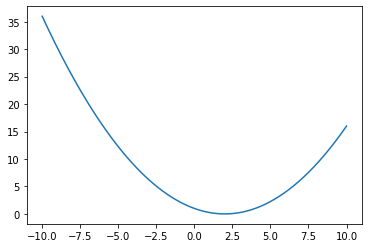

In [81]:
beta = tnp.linspace(-10,10,1000) 
loss = (beta*0.5-1)**2 
plt.plot(beta,loss)

### 방법1: grid search

#### 알고리즘

(1) beta=[-10,-9.99, ... , 9.99, 10]와 같은 수열을 만든다. 

(2) (beta/2-1)^2를 계산한다. 

(3) 2의 결과를 가장 작게 만드는 값을 고른다. 

(풀이) 

체계적으로 쓴것처럼 보이나 그냥 loss를 젤 작게 만드는 beta를 구하면 된다는 당연한 소리임 

[예비학습] tnp.argmin 

In [82]:
tnp.argmin([1,2,-1,1,2])

<tf.Tensor: shape=(), dtype=int64, numpy=2>

In [83]:
tnp.argmin([1,2,1,-1,2])

<tf.Tensor: shape=(), dtype=int64, numpy=3>

예비학습끝

(다시풀이 시작) 

In [84]:
tnp.argmin(loss)

<tf.Tensor: shape=(), dtype=int64, numpy=599>

- 599 인덱스에서 최소값을 가지는군 

In [85]:
beta[599]

<tf.Tensor: shape=(), dtype=float64, numpy=1.9919919919919913>

- $\beta=2$에서 loss가 최소가 되는군 

(의문) beta[600]은 얼마일까? 

In [86]:
beta[600]

<tf.Tensor: shape=(), dtype=float64, numpy=2.0120120120120113>

- 이값보다 beta[599]가 더 loss를 작게 만든다는 것이지? 

In [87]:
(beta[599]/2-1)**2 , (beta[600]/2-1)**2 

(<tf.Tensor: shape=(), dtype=float64, numpy=1.603204806408293e-05>,
 <tf.Tensor: shape=(), dtype=float64, numpy=3.607210814417592e-05>)

- 그러하다 

#### 그리드서치의 문제점 

`-` 비판1: [-10,10]이외에 해가 존재하면? 
- 이 예제의 경우는 운좋게 [-10,10]에서 해가 존재했음
- 하지만 임의의 고정된 $x,y$에 대하여 $loss(\beta)=(x\beta-y)^2$ 의 형태의 해가 항상 [-10,10]에서 존재한다는 보장은 없음
- 해결책: 더 넓게 많은 범위를 탐색하자? 

`-` 비판2: 효율적이지 않음
- 알고리즘을 요약하면 결국 -10부터 10까지 작은 간격으로 조금씩 이동하며 loss를 조사하는 것이 grid search의 아이디어 
- $\to$ 생각해보니까 $\beta=2$인 순간 $loss=(\frac{1}{2}\beta-1)^2=0$이 되어서 이것보다 작은 최소값은 존재하지 않는다(제곱은 항상 양수이어야 하므로)
- $\to$ 따라서 $\beta=2$ 이후로는 탐색할 필요가 없다 

### 방법2: gradient descent

#### 알고리즘

(1) 임의의 초기값을 선정하고 loss를 계산한다. 
 - $\beta=-5 \to loss(-5)=(-5/2-1)^2=12.25$

In [88]:
((-5/2)-1)**2

12.25

(2) 임의의 초기값에서 좌우로 약간씩 이동해보고 loss를 계산한다.
 - 왼쪽으로 이동: $\beta=-5.01,\quad loss(5.01)=12.285025$
 - 오른쪽으로 이동: $\beta=-4.99, \quad loss(-4.99)=12.215025$ 

In [89]:
((-5.01/2)-1)**2

12.285025

In [90]:
((-4.99/2)-1)**2

12.215025

(3) (2)의 결과를 보고 어느쪽으로 이동하는것이 유리한지 따져보고 `유리한 방향으로` 이동한다. 
 - $\beta=-4.99$ 로 이동 


(4) (2)-(3) 의 과정을 반복한다. **왼쪽/오른쪽 모두 가봐도 유리한 지점이 없다면 알고리즘을 멈춘다.**

#### 잠깐 알고리즘 감상 

`-` 알고리즘이 멈추는 지점은 $\beta=2$이다. 왜냐하면 이경우 왼쪽으로 가도, 오른쪽으로 가도 현재 손실함수값보다 크기 때문. 

`-` 이 알고리즘은 $loss=(x\beta-y)^2$의 꼴에서 $[-10,10]$ 이외의 지점에 해가 존재하여도 적절하게 해를 찾을것 이다. 

`-` 또한 비효율적으로 $\beta=2$ 이후에도 탐색을 반복하지 않는다. 

`-` 알고리즘해석 
- (2)의 과정: 손실함수에 미분을 하는 과정으로 볼 수 있음
- (3)의 과정: 미분계수를 해석하여 손실함수를 줄이는 쪽으로 조금씩 $\beta$를 더 좋게 update하는 것으로 볼 수 있음 

> Note: 이처럼 손실함수의 기울기(=경사)를 계산하여 점차적으로 가중치를 업데이트 하는 방식을 경사하강법이라고 부른다. 

#### 왼쪽/오른쪽중에 어디로 갈지 어떻게 판단하는 과정을 수식화?

`-` 미분계수의 의미를 잘 생각하면된다. 
- 미분계수가 양수이다? $\to$ 왼쪽으로 가야한다. 
- 미분계수가 음수이다? $\to$ 오른쪽으로 가야한다. 

`-` 따라서 아래와 같이 수식화 할 수 있다. 

$$\beta_{next} = \begin{cases} \beta_{old} - 0.01 & loss'(\beta_{old})>0 \\ \beta_{old} + 0.01 & loss'(\beta_{old})<0  \end{cases}$$

#### hoxy, 알고리즘을 좀 개선할수 있을까?

`-` 동일하게 0.01씩 이동하는게 맞을까? 

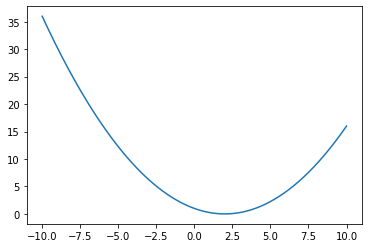

In [91]:
plt.plot(beta,loss)

`-` 위의 그림에서 $\beta=-10$ 일 경우의 접선의 기울기는 $-6$이고 $\beta=-4$ 일때 접선의 기울기는 $-3$이다. 

$\because loss = (0.5\beta-1)^2 \to loss' = 0.5\beta-1$

`-` (아이디어발생) $\beta=-10$ 일 경우에 $0.01$ 움직였다면 $\beta=-4$일 경우에는 $0.005$ 움직이는게 맞다는 의미이다. 

- 움직이는 보폭은 접선의 기울기와 비례하여 움직여야 한다! 경사가 급하면 빨리빨리, 경사가 완만해지면 최소값이 근처에 있다는 의미니가 조심조심 천천히! 

`-` 아이디어를 수식화하자!

$$\beta_{next} \leftarrow \beta_{old} -\alpha \left[\frac{\partial}{\partial \beta} loss(\beta)\right]_{\beta=\beta_{old}}$$

- 아까 수식이랑 좀 다르다? $\to$ 기울기가 양수면 뭔가를 빼고 기울기가 음수면 뭔가를 더하는 구조는 비슷함. (단 $\alpha$가 양수라는 전제가 있어야겠죠) 
- $\alpha$는 양수라고 가정하자. 
- $\alpha$는 더 좋은 $\beta$를 찾기 위해서 **얼마나 조금씩 이동할지를 결정하는 파라메터**
- 앞에서 예로 들었던 $\beta=-10$ 에서 $0.01$만큼 움직이려면 $\alpha=\frac{0.01}{6}$가 된다. 

(개선한 알고리즘을 이용한 풀이) 

**iter1:** beta=-10 출발합시다. 그리고 이동합시다. 얼마나? beta=-10 에서의 미분계수값에 $\alpha$를 곱해서! 

In [92]:
beta = tf.Variable(-10.0) 
beta

<tf.Variable 'Variable:0' shape=() dtype=float32, numpy=-10.0>

In [93]:
with tf.GradientTape(persistent=True) as tape: 
    loss=(beta/2 - 1)**2

In [94]:
tape.gradient(loss,beta)

<tf.Tensor: shape=(), dtype=float32, numpy=-6.0>

In [95]:
alpha = 0.01/6 # 텐서에 상수곱정도는 가능하니까뭐.. 굳이 이거까지 텐서로 하진 맙시다..

In [96]:
beta.assign_sub(alpha*tape.gradient(loss,beta))
beta

<tf.Variable 'Variable:0' shape=() dtype=float32, numpy=-9.99>

- 왜 tf.Variable의 메소드에 assign_add, assign_sub 정도만 구현한지 알겠죠? 이정도만 필요하니까 한거에요 
- persistenct도 왜 디폴트가 False인지 알겠죠? 어차피 한번 기울기를 계산한 지점은 다시 계산할 필요가 없습니다. 그 지점은 바로 업데이트 하거든요 

**iter2:** -9.99 가 되었는데요 여기서 한번 더 이동해 봅시다. 

In [97]:
with tf.GradientTape() as tape: 
    loss=(beta/2 - 1)**2

In [98]:
beta.assign_sub(alpha*tape.gradient(loss,beta))
beta

<tf.Variable 'Variable:0' shape=() dtype=float32, numpy=-9.980008>

- 이제 -9.980008이 되었습니다. 느리지만 조금씩 가고있어요!

**for문**

(수업용)

In [112]:
beta = tf.Variable(-10.0) 
alpha = 0.01/6
for iter in range(10000): 
    with tf.GradientTape(persistent=True) as tape: 
        loss=(beta/2 - 1)**2
    beta.assign_sub(alpha*tape.gradient(loss,beta))
beta

<tf.Variable 'Variable:0' shape=() dtype=float32, numpy=1.997125>

- 오? 

(실제시도1) 100번

In [114]:
beta = tf.Variable(-10.0) 
alpha = 0.01/6
for iter in range(100): 
    with tf.GradientTape(persistent=True) as tape: 
        loss=(beta/2 - 1)**2
    beta.assign_sub(alpha*tape.gradient(loss,beta))
beta

<tf.Variable 'Variable:0' shape=() dtype=float32, numpy=-9.040152>

- 엥?

(실제시도2) 1000번

In [116]:
beta = tf.Variable(-10.0) 
alpha = 0.01/6
for iter in range(1000): 
    with tf.GradientTape(persistent=True) as tape: 
        loss=(beta/2 - 1)**2
    beta.assign_sub(alpha*tape.gradient(loss,beta))
beta

<tf.Variable 'Variable:0' shape=() dtype=float32, numpy=-3.2133687>

- 엥?

`-` 실제로는 가고 있었음.. 그런데 좀 느리게 갔던 것 $\to$ 속도를 빠르게 할 수 있을까? 

#### 학습률 

`-` 아래의 학습과정을 시각화해보자. 

In [126]:
beta = tf.Variable(-10.0) 
alpha = 0.01/6
for iter in range(100): 
    with tf.GradientTape(persistent=True) as tape: 
        loss=(beta/2 - 1)**2
    beta.assign_sub(alpha*tape.gradient(loss,beta))
beta

<tf.Variable 'Variable:0' shape=() dtype=float32, numpy=-9.040152>

##### **[시각화코드 예비학습]**: 시험에 안나옴

`-` 환경설정

In [258]:
plt.rcParams["animation.html"]="jshtml"

In [259]:
from matplotlib import animation 

`-` 도화지와 네모틀 생성 

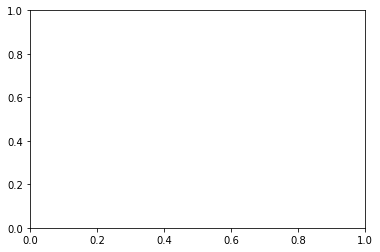

In [293]:
fig = plt.figure() # 도화지 생성, 도화지의 이름은 fig 
ax = fig.add_subplot() # 도화지에 네모틀 생성, 네모틀의 이름은 ax 

In [294]:
type(fig),type(ax)

(matplotlib.figure.Figure, matplotlib.axes._subplots.AxesSubplot)

`-` 도화지와 네모는 포함관계에 있음. 

In [295]:
fig.axes # 도화지에 있는 네모틀을 모두 보여줘~! -> 1개있네?

[<AxesSubplot:>]

In [296]:
fig.axes[0] # 첫번째 원소에 접근 

<AxesSubplot:>

In [297]:
id(fig.axes[0]) # 어떠한 메모리 주소에 있다!

139960545548112

In [298]:
id(ax) # 같은 메모리주소에 있네? 

139960545548112

`-` 그래서 도화지를 출력하면 네모틀도 알아서 출력됨 (네모틀이 없다면 도화지 출력시 아무것도 출력되지 않음) 

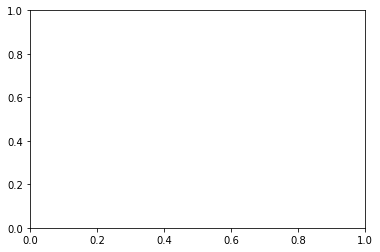

In [299]:
fig

`-` 네모틀(ax)의 특수기능(=메소드)중에는 plot이 있음. 

In [300]:
pnts = ax.plot([1,2,3],[4,5,6],'o') 

In [301]:
pnts # 리스트의 형태로 있음, 네모틀에 다른점이나 선들이 추가될수도 있으니까! 

In [302]:
pnts = pnts[0] # 첫번째원소

- 우변을 실행하면 네모틀안에서 점들이 (1,1), (2,5), (3,6) 위치에 점들이 찍힘. 
- 이 점들의 집합역시 하나의 오브젝트로 볼수 있는데 그 오브젝트를 pnts라고 이름붙임.
- fig $\supset$ ax $\supset$ pnts

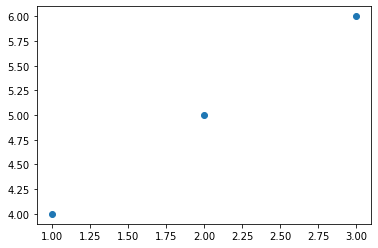

In [303]:
fig

`-` pnts 오브젝트 

In [304]:
pnts

In [305]:
pnts.get_xdata() # pnts 오브젝트의 x 

array([1, 2, 3])

In [306]:
pnts.get_ydata() # pnts 오브젝트의 y

array([4, 5, 6])

In [307]:
pnts.set_ydata([5,5,5])

In [308]:
pnts.get_xdata(),pnts.get_ydata()

(array([1, 2, 3]), [5, 5, 5])

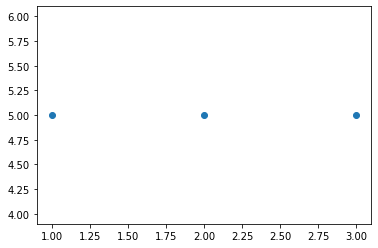

In [309]:
fig

`-` 응용 

In [310]:
def animate(frames): # 입력은 frames
    if frames%2 == 0: 
        pnts.set_ydata([5,5,5])
    else:
        pnts.set_ydata([4,5,6])         

In [313]:
ani = animation.FuncAnimation(fig,animate,frames=30)
ani

예비학습끝 

### tf.keras.optimizers를 이용 

`-` 수식 $\beta_{next} \leftarrow \beta_{old} -\alpha \left[\frac{\partial}{\partial \beta} loss(\beta)\right]_{\beta=\beta_{old}}$ 을 모를때!

`-` 정확한 수식은 모르지만 이상한 초기 $\beta$를 점점 update해서 **그럴듯한** $\beta$로 만드는 느낌은 기억함. 
- 그럴듯한 = 최적의

`-` 그리고 그 방법이 미분을 이용한다는 것도 기억함! 

`-` 그럼 아래와 같은 기능을 수행하는 옵티마이저라는 물체(object)를 만들자! 
- 옵티마이저: ($\beta^{old}$, $\beta^{old}$에서의 미분값) $\to$ $\beta^{new}$

In [108]:
opt = tf.keras.optimizers.SGD(learning_rate =0.01/6) # optimizer 생성 
opt

`-` 이 물체는 현재 아무것도 모르는 상태임 (뭘 최적화 하는지도 모름) 

In [109]:
opt.weights

[]

`-` 옵티마이저에 전달할 값을 

In [71]:
beta= tf.Variable(-10.0) 
with tf.GradientTape(persistent=True) as tape:
    loss=(beta/2-1)**2

In [72]:
opt.apply_gradients([(tape.gradient(loss,beta),beta)])

<tf.Variable 'UnreadVariable' shape=() dtype=int64, numpy=1>

In [74]:
beta

<tf.Variable 'Variable:0' shape=() dtype=float32, numpy=-9.99>

In [75]:
with tf.GradientTape(persistent=True) as tape:
    loss=(beta/2-1)**2

In [76]:
opt.apply_gradients([(tape.gradient(loss,beta),beta)])

<tf.Variable 'UnreadVariable' shape=() dtype=int64, numpy=2>

In [77]:
beta

<tf.Variable 'Variable:0' shape=() dtype=float32, numpy=-9.980008>